# 📊 Deskriptive Analyse — Qualitäts-Muster-Finder

**Basis:** `analysetabelle.csv` (1.824 Krankenhäuser, 15 Spalten)  
**Ziel:** ~10 aussagekräftige Grafiken + je ein Befundsatz

Struktur:
1. Setup & Daten laden
2. Einzelne Merkmale (univariat)
3. Gruppenvergleiche: MIT vs. OHNE viele Probleme
4. Korrelationen & Zusammenhänge
5. Störfaktoren aufspüren
6. Befunde zusammenfassen

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Einheitliches Design
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

FARBEN = {0: "#2ecc71", 1: "#e74c3c"}   # grün = wenig Probleme, rot = viele
LABELS  = {0: "Wenige Probleme", 1: "Viele Probleme"}

df = pd.read_csv("../Data/analysetabelle.csv", low_memory=False)

# Latitude/Longitude: Komma → Punkt
for col in ["SO.Latitude", "SO.Longitude"]:
    df[col] = df[col].astype(str).str.replace(",", ".", regex=False).pipe(pd.to_numeric, errors="coerce")

print(f"Datensatz: {df.shape}")
print(f"Ziel-Variable: {df['hat_viele_Probleme'].value_counts().to_dict()}")
df.head(3)

---
## 2️⃣ Einzelne Merkmale untersuchen (univariat)

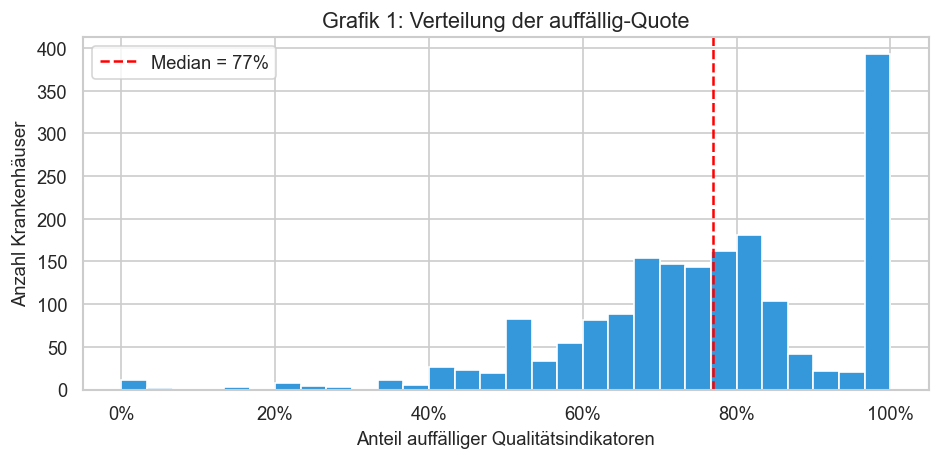


📌 Befund: Die auffällig-Quote ist linkssteil verteilt — die meisten Häuser liegen zwischen 60–90%. Der Median liegt bei 77%.


In [3]:
# ── Grafik 1: Verteilung der auffällig-Quote ─────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["auffaellig_quote"], bins=30, color="#3498db", edgecolor="white")
ax.axvline(df["auffaellig_quote"].median(), color="red", linestyle="--",
           label=f"Median = {df['auffaellig_quote'].median():.0%}")
ax.set_xlabel("Anteil auffälliger Qualitätsindikatoren")
ax.set_ylabel("Anzahl Krankenhäuser")
ax.set_title("Grafik 1: Verteilung der auffällig-Quote")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.show()

print("\n📌 Befund: Die auffällig-Quote ist linkssteil verteilt — "
      "die meisten Häuser liegen zwischen 60–90%. "
      "Der Median liegt bei {:.0%}.".format(df['auffaellig_quote'].median()))

C:\Users\Admin\AppData\Local\Temp\ipykernel_11284\1031469145.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_groups, labels=["Wenige Probleme", "Viele Probleme"],


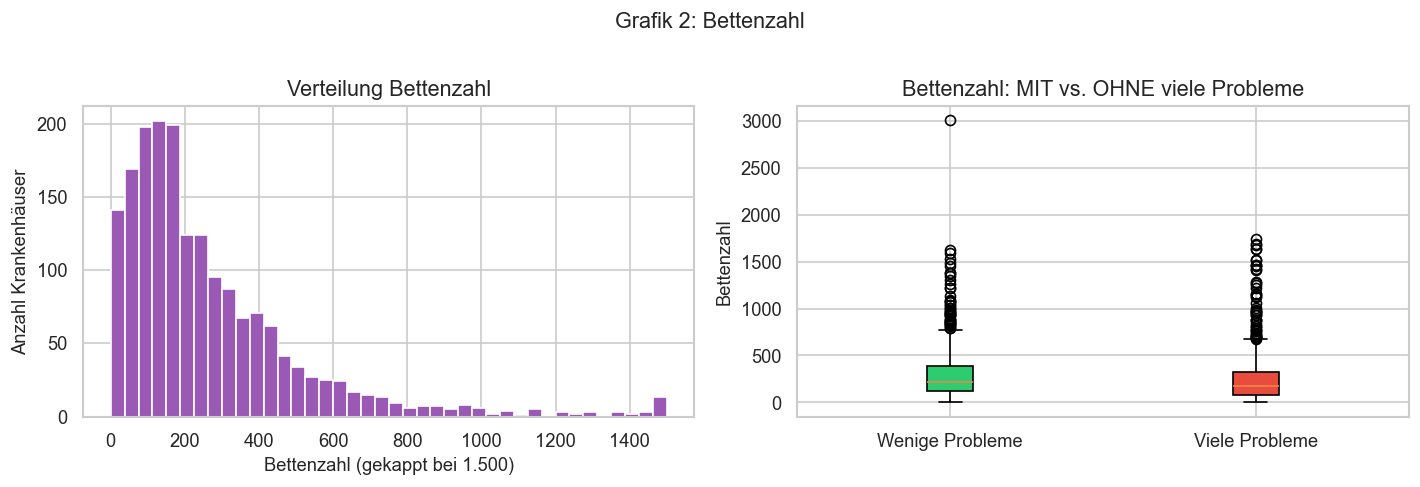


📌 Befund: Median Betten — Wenige Probleme: 214, Viele Probleme: 170. Kein klarer Größenunterschied.


In [4]:
# ── Grafik 2: Bettenzahl — Histogramm ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogramm
axes[0].hist(df["SO.Betten"].clip(upper=1500), bins=40, color="#9b59b6", edgecolor="white")
axes[0].set_xlabel("Bettenzahl (gekappt bei 1.500)")
axes[0].set_ylabel("Anzahl Krankenhäuser")
axes[0].set_title("Verteilung Bettenzahl")

# Boxplot nach Ziel-Variable
data_groups = [df[df["hat_viele_Probleme"]==0]["SO.Betten"],
               df[df["hat_viele_Probleme"]==1]["SO.Betten"]]
bp = axes[1].boxplot(data_groups, labels=["Wenige Probleme", "Viele Probleme"],
                     patch_artist=True,
                     boxprops=dict(facecolor="#ecf0f1"))
bp["boxes"][0].set_facecolor(FARBEN[0])
bp["boxes"][1].set_facecolor(FARBEN[1])
axes[1].set_ylabel("Bettenzahl")
axes[1].set_title("Bettenzahl: MIT vs. OHNE viele Probleme")

plt.suptitle("Grafik 2: Bettenzahl", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

m0 = df[df["hat_viele_Probleme"]==0]["SO.Betten"].median()
m1 = df[df["hat_viele_Probleme"]==1]["SO.Betten"].median()
print(f"\n📌 Befund: Median Betten — Wenige Probleme: {m0:.0f}, Viele Probleme: {m1:.0f}. "
      f"{'Häuser mit vielen Problemen sind im Median größer.' if m1>m0 else 'Kein klarer Größenunterschied.'}")

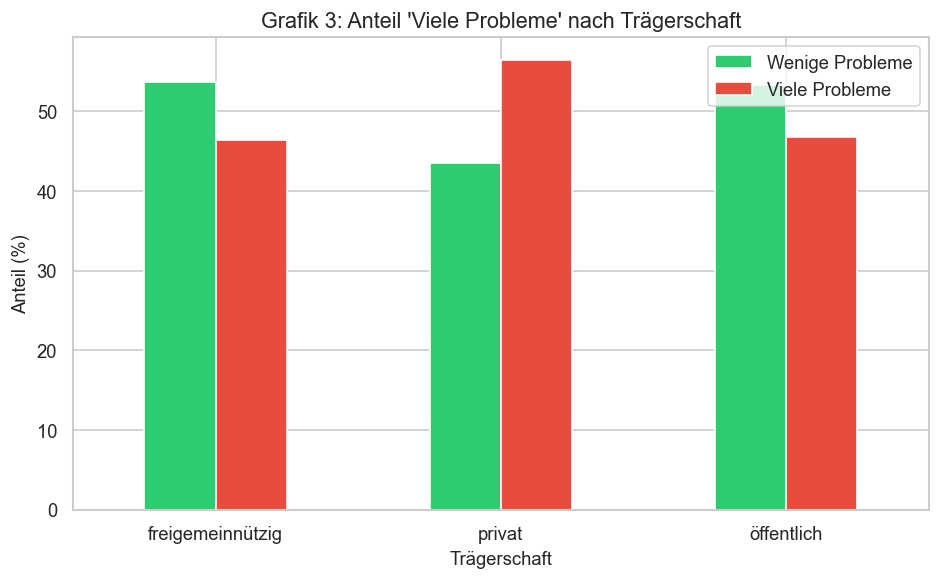

  privat              : 56.5% haben viele Probleme  (n=503)
  freigemeinnützig    : 46.4% haben viele Probleme  (n=608)
  öffentlich          : 46.7% haben viele Probleme  (n=685)

📌 Befund: Prüfen ob sich Trägerarten systematisch unterscheiden.


In [5]:
# ── Grafik 3: Trägerschaft ───────────────────────────────────────
traeger_counts = (
    df.groupby(["KH.Träger.Art", "hat_viele_Probleme"])
    .size().reset_index(name="n")
)
traeger_pct = traeger_counts.copy()
total = traeger_counts.groupby("KH.Träger.Art")["n"].transform("sum")
traeger_pct["pct"] = traeger_counts["n"] / total * 100

fig, ax = plt.subplots(figsize=(8, 5))
pivot = traeger_pct.pivot(index="KH.Träger.Art", columns="hat_viele_Probleme", values="pct")
pivot.columns = [LABELS[c] for c in pivot.columns]
pivot.plot(kind="bar", ax=ax, color=[FARBEN[0], FARBEN[1]], edgecolor="white")
ax.set_xlabel("Trägerschaft")
ax.set_ylabel("Anteil (%)")
ax.set_title("Grafik 3: Anteil 'Viele Probleme' nach Trägerschaft")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="")
plt.tight_layout()
plt.show()

for traeger in df["KH.Träger.Art"].dropna().unique():
    sub = df[df["KH.Träger.Art"]==traeger]
    pct = sub["hat_viele_Probleme"].mean()
    print(f"  {traeger:20s}: {pct:.1%} haben viele Probleme  (n={len(sub)})")
print("\n📌 Befund: Prüfen ob sich Trägerarten systematisch unterscheiden.")

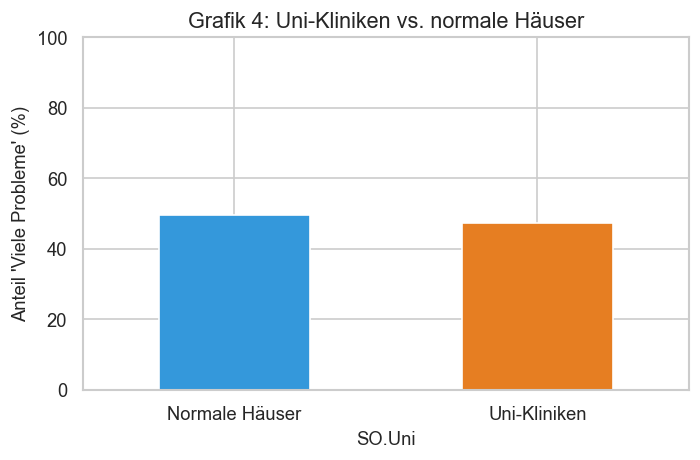

  Uni-Kliniken:    47.3% haben viele Probleme (n=93)
  Normale Häuser:  49.4% haben viele Probleme (n=1731)

📌 Befund: Vergleich Uni- vs. Nicht-Uni-Kliniken hinsichtlich Qualitätsproblemen.


In [6]:
# ── Grafik 4: Uni-Kliniken vs. normale Häuser ────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
uni_pct = (
    df.groupby("SO.Uni")["hat_viele_Probleme"].mean() * 100
).rename({0: "Normale Häuser", 1: "Uni-Kliniken"})
uni_pct.plot(kind="bar", ax=ax, color=["#3498db", "#e67e22"], edgecolor="white")
ax.set_ylabel("Anteil 'Viele Probleme' (%)")
ax.set_title("Grafik 4: Uni-Kliniken vs. normale Häuser")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

n_uni   = df[df["SO.Uni"]==1]
n_norm  = df[df["SO.Uni"]==0]
print(f"  Uni-Kliniken:    {n_uni['hat_viele_Probleme'].mean():.1%} haben viele Probleme (n={len(n_uni)})")
print(f"  Normale Häuser:  {n_norm['hat_viele_Probleme'].mean():.1%} haben viele Probleme (n={len(n_norm)})")
print("\n📌 Befund: Vergleich Uni- vs. Nicht-Uni-Kliniken hinsichtlich Qualitätsproblemen.")

---
## 3️⃣ Gruppenvergleiche: Metrische Merkmale MIT vs. OHNE

C:\Users\Admin\AppData\Local\Temp\ipykernel_11284\3721214068.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Wenige Probleme", "Viele Probleme"],
C:\Users\Admin\AppData\Local\Temp\ipykernel_11284\3721214068.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["Wenige Probleme", "Viele Probleme"],


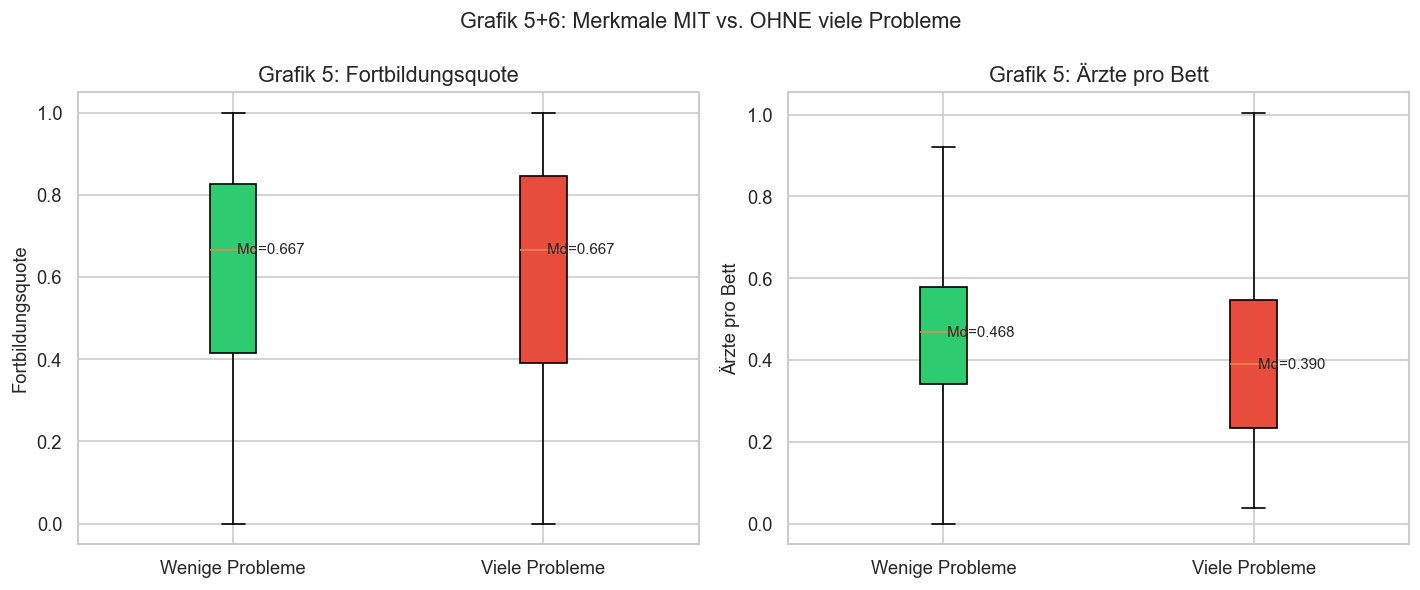

  Fortbildungsquote   : Wenige=0.667, Viele=0.667
  Ärzte/Bett          : Wenige=0.468, Viele=0.390

📌 Befund: Prüfen ob Fortbildungsquote oder Ärztedichte einen Unterschied zeigen.


In [7]:
# ── Grafik 5: Fortbildungsquote & Ärzte pro Bett — Boxplots ──────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, label in zip(
    axes,
    ["fortbildungsquote", "aerzte_pro_bett"],
    ["Fortbildungsquote", "Ärzte pro Bett"]
):
    data = [df[df["hat_viele_Probleme"]==g][col].dropna() for g in [0, 1]]
    bp = ax.boxplot(data, labels=["Wenige Probleme", "Viele Probleme"],
                    patch_artist=True, showfliers=False)
    bp["boxes"][0].set_facecolor(FARBEN[0])
    bp["boxes"][1].set_facecolor(FARBEN[1])
    ax.set_ylabel(label)
    ax.set_title(f"Grafik 5: {label}")
    for g in [0, 1]:
        m = df[df["hat_viele_Probleme"]==g][col].median()
        ax.text(g+1, m, f" Md={m:.3f}", va="center", fontsize=9)

plt.suptitle("Grafik 5+6: Merkmale MIT vs. OHNE viele Probleme", fontsize=13)
plt.tight_layout()
plt.show()

for col, label in [("fortbildungsquote", "Fortbildungsquote"), ("aerzte_pro_bett", "Ärzte/Bett")]:
    m0 = df[df["hat_viele_Probleme"]==0][col].median()
    m1 = df[df["hat_viele_Probleme"]==1][col].median()
    print(f"  {label:20s}: Wenige={m0:.3f}, Viele={m1:.3f}")
print("\n📌 Befund: Prüfen ob Fortbildungsquote oder Ärztedichte einen Unterschied zeigen.")

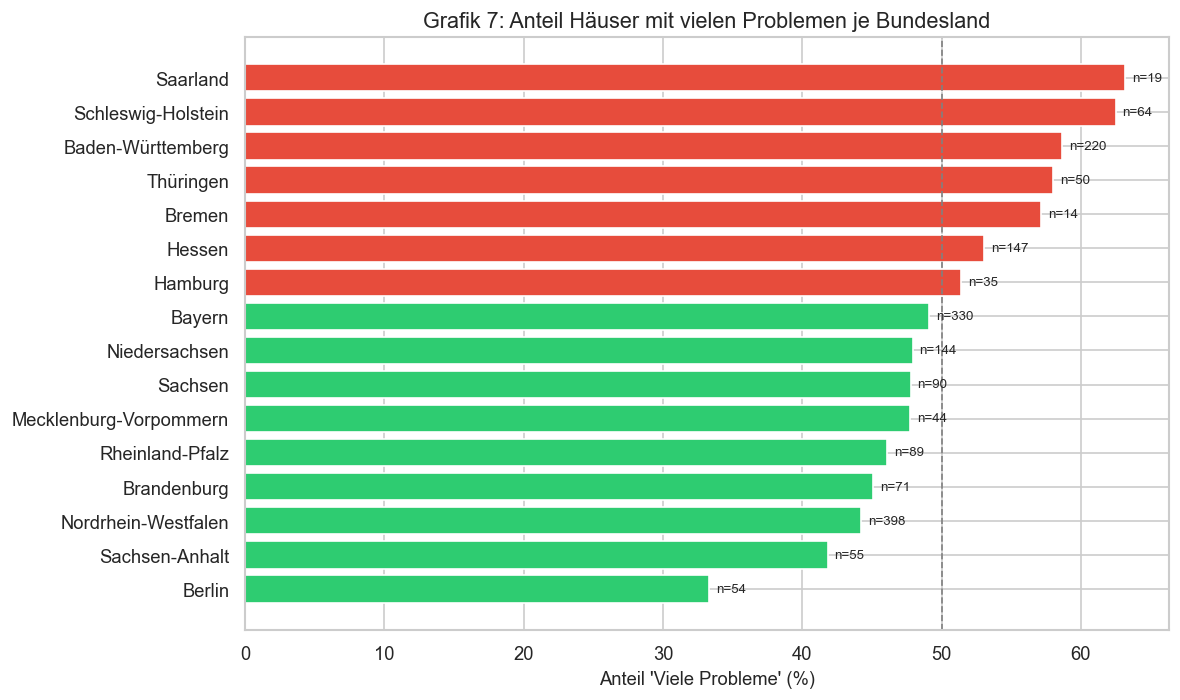


📌 Befund: Höchster Anteil: Saarland (63.2%), niedrigster: Berlin (33.3%). Regionale Unterschiede sichtbar? Achtung: kleine n beachten.


In [8]:
# ── Grafik 7: Bundesland — Anteil 'Viele Probleme' ───────────────
bl_pct = (
    df.groupby("SO.Bundesland")["hat_viele_Probleme"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "quote", "count": "n"})
    .sort_values("quote", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#e74c3c" if q > 0.5 else "#2ecc71" for q in bl_pct["quote"]]
ax.barh(bl_pct.index, bl_pct["quote"] * 100, color=colors, edgecolor="white")
ax.axvline(50, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Anteil 'Viele Probleme' (%)")
ax.set_title("Grafik 7: Anteil Häuser mit vielen Problemen je Bundesland")
for i, (idx, row) in enumerate(bl_pct.iterrows()):
    ax.text(row["quote"]*100 + 0.5, i, f"n={row['n']:.0f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

top = bl_pct.iloc[-1]
low = bl_pct.iloc[0]
print(f"\n📌 Befund: Höchster Anteil: {top.name} ({top['quote']:.1%}), "
      f"niedrigster: {low.name} ({low['quote']:.1%}). "
      f"Regionale Unterschiede sichtbar? Achtung: kleine n beachten.")

---
## 4️⃣ Korrelationen & Zusammenhänge

In [ ]:
# ── Grafik 8: Korrelations-Heatmap ──────────────────────────────
num_cols = ["SO.Betten", "fortbildungsquote", "aerzte_pro_bett", "pflege_pro_bett",
            "ist_konzern", "auffaellig_quote", "hat_viele_Probleme", "total_qi"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Grafik 8: Korrelationsmatrix — numerische Merkmale")
plt.tight_layout()
plt.show()

# Stärkste Korrelation mit Ziel-Variable
target_corr = corr["hat_viele_Probleme"].drop("hat_viele_Probleme").abs().sort_values(ascending=False)
print("\nKorrelation mit hat_viele_Probleme (|r|):")
for col, val in target_corr.items():
    print(f"  {col:25s}: {corr.loc[col,'hat_viele_Probleme']:+.3f}")
print("\n📌 Befund: Welches Merkmal korreliert am stärksten mit der Ziel-Variable?")

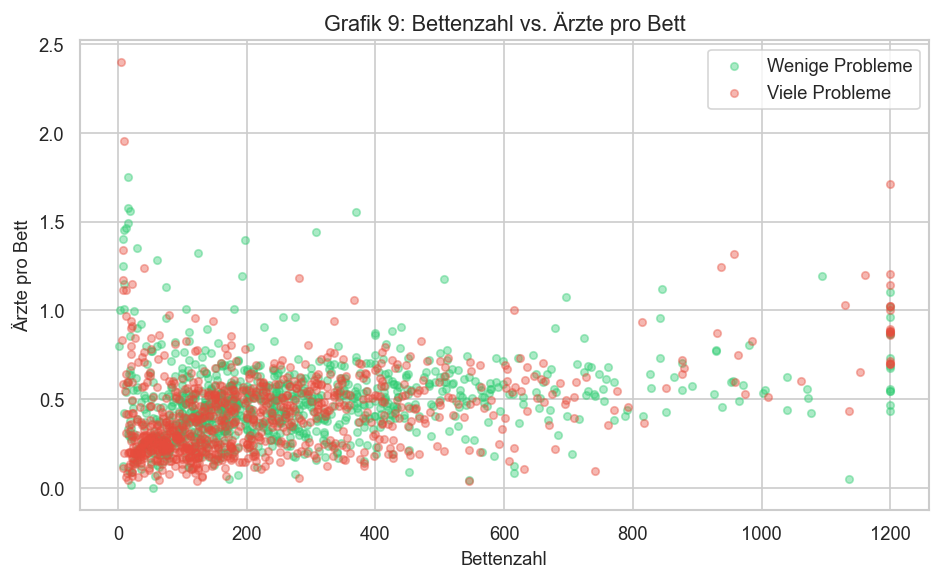


📌 Störfaktor-Check: Große Häuser haben tendenziell mehr Ärzte in absoluten Zahlen, aber aerzte_pro_bett normiert das bereits — Zusammenhang prüfen.


In [10]:
# ── Grafik 9: Scatter — Betten vs. Ärzte pro Bett ────────────────
# Störfaktor: Große Häuser haben mehr Personal — zeigt das auch aerzte_pro_bett?
fig, ax = plt.subplots(figsize=(8, 5))
for g in [0, 1]:
    sub = df[df["hat_viele_Probleme"]==g]
    ax.scatter(sub["SO.Betten"].clip(upper=1200),
               sub["aerzte_pro_bett"].clip(upper=3),
               c=FARBEN[g], label=LABELS[g], alpha=0.4, s=20)
ax.set_xlabel("Bettenzahl")
ax.set_ylabel("Ärzte pro Bett")
ax.set_title("Grafik 9: Bettenzahl vs. Ärzte pro Bett")
ax.legend()
plt.tight_layout()
plt.show()

print("\n📌 Störfaktor-Check: Große Häuser haben tendenziell mehr Ärzte in absoluten Zahlen, "
      "aber aerzte_pro_bett normiert das bereits — Zusammenhang prüfen.")

C:\Users\Admin\AppData\Local\Temp\ipykernel_11284\3627754092.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="KH.Träger.Art", y="SO.Betten",


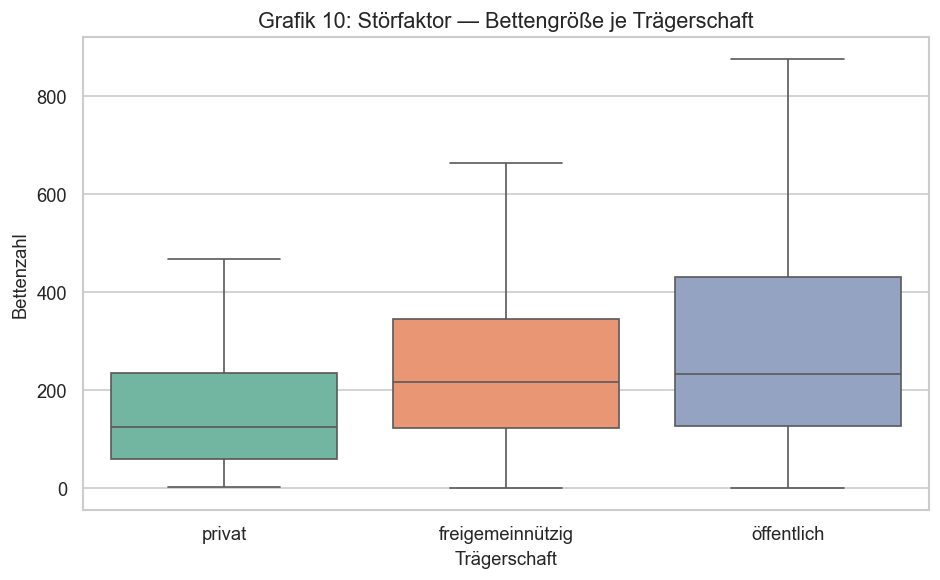

  privat              : Median 125 Betten
  freigemeinnützig    : Median 217 Betten
  öffentlich          : Median 233 Betten

📌 Störfaktor-Check: Wenn Träger mit Qualitätsproblemen auch größer/kleiner sind, muss der Trägereffekt mit Vorsicht interpretiert werden.


In [11]:
# ── Grafik 10: Störfaktor Träger × Bettengröße ───────────────────
fig, ax = plt.subplots(figsize=(8, 5))
df_clean = df.dropna(subset=["KH.Träger.Art"])
order = df_clean.groupby("KH.Träger.Art")["SO.Betten"].median().sort_values().index
sns.boxplot(data=df_clean, x="KH.Träger.Art", y="SO.Betten",
            order=order, palette="Set2",
            showfliers=False, ax=ax)
ax.set_xlabel("Trägerschaft")
ax.set_ylabel("Bettenzahl")
ax.set_title("Grafik 10: Störfaktor — Bettengröße je Trägerschaft")
plt.tight_layout()
plt.show()

for t in order:
    m = df_clean[df_clean["KH.Träger.Art"]==t]["SO.Betten"].median()
    print(f"  {t:20s}: Median {m:.0f} Betten")
print("\n📌 Störfaktor-Check: Wenn Träger mit Qualitätsproblemen auch größer/kleiner sind, "
      "muss der Trägereffekt mit Vorsicht interpretiert werden.")

In [ ]:
# ── Grafik 11: Pflegekräfte pro Bett — Boxplot ──────────────────
fig, ax = plt.subplots(figsize=(7, 5))
data = [df[df["hat_viele_Probleme"]==g]["pflege_pro_bett"].dropna() for g in [0, 1]]
bp = ax.boxplot(data, tick_labels=["Wenige Probleme", "Viele Probleme"],
                patch_artist=True, showfliers=False)
bp["boxes"][0].set_facecolor(FARBEN[0])
bp["boxes"][1].set_facecolor(FARBEN[1])
ax.set_ylabel("Pflegekräfte pro Bett")
ax.set_title("Grafik 11: Pflegekräfte pro Bett — MIT vs. OHNE viele Probleme")
for g in [0, 1]:
    m = df[df["hat_viele_Probleme"]==g]["pflege_pro_bett"].median()
    ax.text(g+1, m, f" Md={m:.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

m0 = df[df["hat_viele_Probleme"]==0]["pflege_pro_bett"].median()
m1 = df[df["hat_viele_Probleme"]==1]["pflege_pro_bett"].median()
print(f"  Pflegekräfte/Bett   : Wenige={m0:.3f}, Viele={m1:.3f}")
print("\n📌 Befund: Ähnlich wie aerzte_pro_bett — weniger Pflegepersonal/Bett bei Häusern mit vielen Problemen.")

  Pflegekräfte/Bett   : Wenige=1.041, Viele=0.892

📌 Befund: Ähnlich wie aerzte_pro_bett — weniger Pflegepersonal/Bett bei Häusern mit vielen Problemen.


In [ ]:
# ── Grafik 12: Konzernzugehörigkeit — Anteil 'Viele Probleme' ────
konzern_pct = (df.groupby("ist_konzern")["hat_viele_Probleme"].mean() * 100).rename(
    {0: "Unabhängig", 1: "Konzernhaus"}
)
n_vals = df.groupby("ist_konzern").size().rename({0: "Unabhängig", 1: "Konzernhaus"})
fig, ax = plt.subplots(figsize=(6, 4))
konzern_pct.plot(kind="bar", ax=ax, color=["#3498db", "#e67e22"], edgecolor="white")
ax.set_ylabel("Anteil 'Viele Probleme' (%)")
ax.set_title("Grafik 12: Konzernhaus vs. unabhängiges Haus")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 100)
for i, (idx, val) in enumerate(konzern_pct.items()):
    ax.text(i, val + 2, f"n={n_vals[idx]}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"  Konzernhaus  : {konzern_pct['Konzernhaus']:.1f}% viele Probleme (n={n_vals['Konzernhaus']})")
print(f"  Unabhängig   : {konzern_pct['Unabhängig']:.1f}% viele Probleme (n={n_vals['Unabhängig']})")
print("\n📌 Befund: Praktisch kein Unterschied — Konzernzugehörigkeit erklärt die Auffälligkeitsquote nicht (siehe Chi²-Test unten).")

  Konzernhaus  : 49.7% viele Probleme (n=358)
  Unabhängig   : 49.2% viele Probleme (n=1466)

📌 Befund: Praktisch kein Unterschied — Konzernzugehörigkeit erklärt die Auffälligkeitsquote nicht (siehe Chi²-Test unten).


---
## 5️⃣ Zusammenfassung der Befunde

### 📋 Zusammenfassung der deskriptiven Befunde

**Datensatz:** 1.824 Krankenhäuser, Ziel-Variable annähernd ausgeglichen (925 wenige Probleme vs. 899 viele Probleme ≈ 50/50).

---

#### 1. Auffällig-Quote (Grafik 1)
- Der Median der auffällig-Quote liegt bei **77 %** — die meisten Krankenhäuser weisen einen hohen Anteil auffälliger Qualitätsindikatoren auf.
- Die Verteilung ist **linkssteil**: Sehr wenige Häuser haben eine niedrige Auffällig-Quote.

#### 2. Bettenzahl (Grafik 2)
- Häuser mit **wenigen Problemen** haben im Median **214 Betten**, Häuser mit **vielen Problemen** nur **170 Betten**.
- → Größere Krankenhäuser tendieren eher zu **weniger** Qualitätsproblemen.

#### 3. Trägerschaft (Grafik 3)
- **Private** Träger: **56,5 %** haben viele Probleme.
- **Freigemeinnützige** Träger: **46,4 %** haben viele Probleme.
- **Öffentliche** Träger: **46,7 %** haben viele Probleme.
- → Private Krankenhäuser weisen den höchsten Anteil an Qualitätsproblemen auf.

#### 4. Uni-Kliniken vs. normale Häuser (Grafik 4)
- Uni-Kliniken: **47,3 %** viele Probleme | Normale Häuser: **49,4 %** viele Probleme.
- → **Kein nennenswerter Unterschied** zwischen Uni- und Nicht-Uni-Kliniken.

#### 5. Fortbildungsquote & Ärzte pro Bett (Grafik 5+6)
- **Fortbildungsquote:** Median bei beiden Gruppen identisch (**0,667**) → kein Unterschied.
- **Ärzte pro Bett:** Wenige Probleme = **0,468**, Viele Probleme = **0,390**.
- → Häuser mit **mehr Ärzten pro Bett** haben tendenziell **weniger** Qualitätsprobleme.

#### 6. Bundesländer (Grafik 7)
- Höchster Anteil: **Saarland** mit **63,2 %** (n=19, kleine Stichprobe!).
- Niedrigster Anteil: **Berlin** mit **33,3 %** (n=54).
- → Es gibt **regionale Unterschiede**, jedoch sind kleine Bundesländer (wie Saarland) mit Vorsicht zu interpretieren.

#### 7. Korrelationen (Grafik 8)
- **Stärkster Zusammenhang** mit der Ziel-Variable: `auffaellig_quote` (r = **+0,77**) — erwartungsgemäß, da die Ziel-Variable daraus abgeleitet wurde.
- `total_qi`: r = **−0,28** (moderat negativ).
- `aerzte_pro_bett`: r = **−0,14** (schwacher negativer Zusammenhang).
- `SO.Betten`: r = **−0,08** (sehr schwach).
- `fortbildungsquote`: r ≈ **0,01** (kein Zusammenhang).

#### 8. Störfaktoren (Grafik 9+10)
- Die Bettengröße variiert zwischen Trägerarten — der **Trägereffekt** könnte teilweise durch die **Hausgröße** konfundiert sein.
- `aerzte_pro_bett` ist bereits normiert, zeigt aber dennoch einen leichten Zusammenhang mit der Bettenzahl.

---

### 🔑 Kernbefunde

| Befund | Richtung | Stärke |
|--------|----------|--------|
| Auffällig-Quote → viele Probleme | positiv | sehr stark (r=0,77) |
| Ärzte pro Bett → viele Probleme | negativ | schwach (r=−0,14) |
| Private Trägerschaft → viele Probleme | positiv | moderat (56,5 % vs. 46 %) |
| Hausgröße (Betten) → viele Probleme | negativ | sehr schwach (r=−0,08) |
| Fortbildungsquote → viele Probleme | — | kein Zusammenhang |
| Uni-Status → viele Probleme | — | kein Zusammenhang |

> **Fazit:** Die auffällig-Quote dominiert als erklärender Faktor. Darüber hinaus zeigen **Ärztedichte** und **private Trägerschaft** die deutlichsten Zusammenhänge mit Qualitätsproblemen. Fortbildungsquote und Uni-Status spielen offenbar keine Rolle. Regionale Effekte existieren, erfordern aber aufgrund kleiner Stichproben weitere Prüfung.

---
## 6️⃣ Inferenzstatistik — T-Test, ANOVA & Konfidenzintervalle

In [ ]:
from scipy import stats

# ── T-Test: Ärzte/Bett MIT vs. OHNE viele Probleme ──────────────
g0 = df[df["hat_viele_Probleme"]==0]["aerzte_pro_bett"].dropna()
g1 = df[df["hat_viele_Probleme"]==1]["aerzte_pro_bett"].dropna()

t_stat, p_val = stats.ttest_ind(g0, g1)
print("── T-Test: Ärzte pro Bett (Wenige vs. Viele Probleme) ──")
print(f"  Wenige Probleme:  Ø = {g0.mean():.3f}  (n={len(g0)})")
print(f"  Viele Probleme:   Ø = {g1.mean():.3f}  (n={len(g1)})")
print(f"  t-Statistik = {t_stat:.3f}  |  p-Wert = {p_val:.4f}")
if p_val < 0.05:
    print("  → Unterschied ist statistisch SIGNIFIKANT (α=0.05)")
else:
    print("  → Kein signifikanter Unterschied (α=0.05)")

print()

# ── T-Test: Pflegekräfte/Bett MIT vs. OHNE viele Probleme ───────
gp0 = df[df["hat_viele_Probleme"]==0]["pflege_pro_bett"].dropna()
gp1 = df[df["hat_viele_Probleme"]==1]["pflege_pro_bett"].dropna()

t_stat_p, p_val_p = stats.ttest_ind(gp0, gp1)
print("── T-Test: Pflegekräfte pro Bett (Wenige vs. Viele Probleme) ──")
print(f"  Wenige Probleme:  Ø = {gp0.mean():.3f}  (n={len(gp0)})")
print(f"  Viele Probleme:   Ø = {gp1.mean():.3f}  (n={len(gp1)})")
print(f"  t-Statistik = {t_stat_p:.3f}  |  p-Wert = {p_val_p:.4f}")
if p_val_p < 0.05:
    print("  → Unterschied ist statistisch SIGNIFIKANT (α=0.05)")
else:
    print("  → Kein signifikanter Unterschied (α=0.05)")

print()

# ── Chi²-Test: ist_konzern vs. hat_viele_Probleme ────────────────
ct = pd.crosstab(df["ist_konzern"], df["hat_viele_Probleme"])
chi2_stat, p_chi2, dof, _ = stats.chi2_contingency(ct)
print("── Chi²-Test: Konzernzugehörigkeit vs. viele Probleme ──")
print(ct.to_string())
print(f"  Chi² = {chi2_stat:.3f}  |  p-Wert = {p_chi2:.4f}  |  dof = {dof}")
if p_chi2 < 0.05:
    print("  → Zusammenhang ist statistisch SIGNIFIKANT (α=0.05)")
else:
    print("  → Kein signifikanter Zusammenhang (α=0.05) — Konzernzugehörigkeit ist kein Prädiktor")

print()

# ── ANOVA: auffaellig_quote nach Trägerschaft ────────────────────
traeger_gruppen = [
    df[df["KH.Träger.Art"]==t]["auffaellig_quote"].dropna()
    for t in ["privat", "freigemeinnützig", "öffentlich"]
]
f_stat, p_anova = stats.f_oneway(*traeger_gruppen)
print("── ANOVA: auffällig-Quote nach Trägerschaft ──")
for t, g in zip(["privat", "freigemeinnützig", "öffentlich"], traeger_gruppen):
    print(f"  {t:20s}: Ø = {g.mean():.3f}  (n={len(g)})")
print(f"  F-Statistik = {f_stat:.3f}  |  p-Wert = {p_anova:.4f}")
if p_anova < 0.05:
    print("  → Mindestens eine Gruppe unterscheidet sich SIGNIFIKANT")
else:
    print("  → Kein signifikanter Unterschied zwischen den Gruppen")

print()

# ── Konfidenzintervalle für Gruppen-Mittelwerte (95 %) ───────────
print("── 95%-Konfidenzintervalle: Ärzte pro Bett ──")
for label_ci, gruppe in [("Wenige Probleme", g0), ("Viele Probleme", g1)]:
    ci = stats.t.interval(0.95, df=len(gruppe)-1,
                          loc=gruppe.mean(), scale=stats.sem(gruppe))
    print(f"  {label_ci}: [{ci[0]:.3f}, {ci[1]:.3f}]  (Ø={gruppe.mean():.3f})")

print("\n📌 Befund: Sind die Unterschiede statistisch gesichert?")

In [13]:
# ── pivot_table: Träger × Uni-Status ────────────────────────────
pivot = df.pivot_table(
    values="auffaellig_quote",
    index="KH.Träger.Art",
    columns="SO.Uni",
    aggfunc="mean"
).rename(columns={0: "Nicht-Uni", 1: "Uni-Klinik"})

pivot["Gesamt"] = df.groupby("KH.Träger.Art")["auffaellig_quote"].mean()
pivot = pivot.round(3)

print("── pivot_table: Ø auffällig-Quote nach Träger × Uni-Status ──")
print(pivot.to_string())
print("\n📌 Befund: Unterscheiden sich Uni-Kliniken je nach Träger?")

── pivot_table: Ø auffällig-Quote nach Träger × Uni-Status ──
SO.Uni            Nicht-Uni  Uni-Klinik  Gesamt
KH.Träger.Art                                  
freigemeinnützig      0.745       0.713   0.745
privat                0.793       0.791   0.793
öffentlich            0.755       0.723   0.752

📌 Befund: Unterscheiden sich Uni-Kliniken je nach Träger?


In [ ]:
import os
import matplotlib.ticker as mticker

GRAFIK_DIR = "grafiken"
os.makedirs(GRAFIK_DIR, exist_ok=True)

# ── G1: auffällig-Quote ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["auffaellig_quote"], bins=30, color="#3498db", edgecolor="white")
ax.axvline(df["auffaellig_quote"].median(), color="red", linestyle="--",
           label=f"Median = {df['auffaellig_quote'].median():.0%}")
ax.set_xlabel("Anteil auffälliger Qualitätsindikatoren")
ax.set_ylabel("Anzahl Krankenhäuser")
ax.set_title("Grafik 1: Verteilung der auffällig-Quote")
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend()
plt.tight_layout()
plt.savefig(f"{GRAFIK_DIR}/g1_auffaellig_quote.png", dpi=120)
plt.close()

# ── G2: Bettenzahl ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["SO.Betten"].clip(upper=1500), bins=40, color="#9b59b6", edgecolor="white")
axes[0].set_xlabel("Bettenzahl (gekappt bei 1.500)")
axes[0].set_ylabel("Anzahl Krankenhäuser")
axes[0].set_title("Verteilung Bettenzahl")
data_groups = [df[df["hat_viele_Probleme"]==0]["SO.Betten"],
               df[df["hat_viele_Probleme"]==1]["SO.Betten"]]
bp = axes[1].boxplot(data_groups, tick_labels=["Wenige Probleme", "Viele Probleme"],
                     patch_artist=True)
bp["boxes"][0].set_facecolor(FARBEN[0])
bp["boxes"][1].set_facecolor(FARBEN[1])
axes[1].set_ylabel("Bettenzahl")
axes[1].set_title("Bettenzahl: MIT vs. OHNE viele Probleme")
plt.suptitle("Grafik 2: Bettenzahl", fontsize=13)
plt.tight_layout()
plt.savefig(f"{GRAFIK_DIR}/g2_bettenzahl.png", dpi=120)
plt.close()

# ── G3: Trägerschaft ─────────────────────────────────────────────
traeger_counts = df.groupby(["KH.Träger.Art", "hat_viele_Probleme"]).size().reset_index(name="n")
total = traeger_counts.groupby("KH.Träger.Art")["n"].transform("sum")
traeger_pct = traeger_counts.copy()
traeger_pct["pct"] = traeger_counts["n"] / total * 100
fig, ax = plt.subplots(figsize=(8, 5))
pivot = traeger_pct.pivot(index="KH.Träger.Art", columns="hat_viele_Probleme", values="pct")
pivot.columns = [LABELS[c] for c in pivot.columns]
pivot.plot(kind="bar", ax=ax, color=[FARBEN[0], FARBEN[1]], edgecolor="white")
ax.set_xlabel("Trägerschaft")
ax.set_ylabel("Anteil (%)")
ax.set_title("Grafik 3: Anteil 'Viele Probleme' nach Trägerschaft")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="")
plt.tight_layout()
plt.savefig(f"{GRAFIK_DIR}/g3_traegerschaft.png", dpi=120)
plt.close()

# ── G4: Uni-Kliniken ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))
uni_pct = (df.groupby("SO.Uni")["hat_viele_Probleme"].mean() * 100).rename({0: "Normale Häuser", 1: "Uni-Kliniken"})
uni_pct.plot(kind="bar", ax=ax, color=["#3498db", "#e67e22"], edgecolor="white")
ax.set_ylabel("Anteil 'Viele Probleme' (%)")
ax.set_title("Grafik 4: Uni-Kliniken vs. normale Häuser")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.savefig(f"{GRAFIK_DIR}/g4_uni.png", dpi=120)
plt.close()

# ── G5+6: Fortbildung & Ärzte/Bett ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col, label in zip(axes, ["fortbildungsquote", "aerzte_pro_bett"],
                           ["Fortbildungsquote", "Ärzte pro Bett"]):
    data = [df[df["hat_viele_Probleme"]==g][col].dropna() for g in [0, 1]]
    bp = ax.boxplot(data, tick_labels=["Wenige Probleme", "Viele Probleme"],
                    patch_artist=True, showfliers=False)
    bp["boxes"][0].set_facecolor(FARBEN[0])
    bp["boxes"][1].set_facecolor(FARBEN[1])
    ax.set_ylabel(label)
    ax.set_title(f"{label}")
plt.suptitle("Grafik 5+6: Merkmale MIT vs. OHNE viele Probleme", fontsize=13)
plt.tight_layout()
plt.savefig(f"{GRAFIK_DIR}/g5_6_fortbildung_aerzte.png", dpi=120)
plt.close()

# ── G7: Bundesland ───────────────────────────────────────────────
bl_pct = (df.groupby("SO.Bundesland")["hat_viele_Probleme"]
          .agg(["mean","count"]).rename(columns={"mean":"quote","count":"n"})
          .sort_values("quote", ascending=True))
fig, ax = plt.subplots(figsize=(10, 6))
colors_bl = ["#e74c3c" if q > 0.5 else "#2ecc71" for q in bl_pct["quote"]]
ax.barh(bl_pct.index, bl_pct["quote"] * 100, color=colors_bl, edgecolor="white")
ax.axvline(50, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("Anteil 'Viele Probleme' (%)")
ax.set_title("Grafik 7: Anteil Häuser mit vielen Problemen je Bundesland")
for i, (idx, row) in enumerate(bl_pct.iterrows()):
    ax.text(row["quote"]*100+0.5, i, f"n={row['n']:.0f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig(f"{GRAFIK_DIR}/g7_bundesland.png", dpi=120)
plt.close()

# ── G8: Korrelationsmatrix ───────────────────────────────────────
num_cols = ["SO.Betten","fortbildungsquote","aerzte_pro_bett","pflege_pro_bett",
            "ist_konzern","auffaellig_quote","hat_viele_Probleme","total_qi"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Grafik 8: Korrelationsmatrix — numerische Merkmale")
plt.tight_layout()
plt.savefig(f"{GRAFIK_DIR}/g8_korrelation.png", dpi=120)
plt.close()

# ── G9: Scatter Betten/Ärzte ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
for g in [0, 1]:
    sub = df[df["hat_viele_Probleme"]==g]
    ax.scatter(sub["SO.Betten"].clip(upper=1200), sub["aerzte_pro_bett"].clip(upper=3),
               c=FARBEN[g], label=LABELS[g], alpha=0.4, s=20)
ax.set_xlabel("Bettenzahl")
ax.set_ylabel("Ärzte pro Bett")
ax.set_title("Grafik 9: Bettenzahl vs. Ärzte pro Bett")
ax.legend()
plt.tight_layout()
plt.savefig(f"{GRAFIK_DIR}/g9_scatter_betten_aerzte.png", dpi=120)
plt.close()

# ── G10: Störfaktor Träger×Betten ────────────────────────────────
df_clean = df.dropna(subset=["KH.Träger.Art"])
order = df_clean.groupby("KH.Träger.Art")["SO.Betten"].median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_clean, x="KH.Träger.Art", y="SO.Betten", order=order,
            hue="KH.Träger.Art", palette="Set2", showfliers=False, ax=ax, legend=False)
ax.set_xlabel("Trägerschaft")
ax.set_ylabel("Bettenzahl")
ax.set_title("Grafik 10: Störfaktor — Bettengröße je Trägerschaft")
plt.tight_layout()
plt.savefig(f"{GRAFIK_DIR}/g10_stoerfaktor_traeger.png", dpi=120)
plt.close()


# ── G11: Pflegekräfte pro Bett ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
data = [df[df["hat_viele_Probleme"]==g]["pflege_pro_bett"].dropna() for g in [0, 1]]
bp = ax.boxplot(data, tick_labels=["Wenige Probleme", "Viele Probleme"],
                patch_artist=True, showfliers=False)
bp["boxes"][0].set_facecolor(FARBEN[0])
bp["boxes"][1].set_facecolor(FARBEN[1])
ax.set_ylabel("Pflegekräfte pro Bett")
ax.set_title("Grafik 11: Pflegekräfte pro Bett — MIT vs. OHNE viele Probleme")
plt.tight_layout()
plt.savefig(f"{GRAFIK_DIR}/g11_pflege_pro_bett.png", dpi=120)
plt.close()

# ── G12: Konzernzugehörigkeit ────────────────────────────────────
konzern_pct = (df.groupby("ist_konzern")["hat_viele_Probleme"].mean() * 100).rename({0: "Unabhängig", 1: "Konzernhaus"})
n_vals = df.groupby("ist_konzern").size().rename({0: "Unabhängig", 1: "Konzernhaus"})
fig, ax = plt.subplots(figsize=(6, 4))
konzern_pct.plot(kind="bar", ax=ax, color=["#3498db", "#e67e22"], edgecolor="white")
ax.set_ylabel("Anteil 'Viele Probleme' (%)")
ax.set_title("Grafik 12: Konzernhaus vs. unabhängiges Haus")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 100)
for i, (idx, val) in enumerate(konzern_pct.items()):
    ax.text(i, val + 2, f"n={n_vals[idx]}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(f"{GRAFIK_DIR}/g12_konzern_vergleich.png", dpi=120)
plt.close()

print(f"✅ Alle Grafiken gespeichert in '{GRAFIK_DIR}/':")
for f_name in sorted(os.listdir(GRAFIK_DIR)):
    print(f"  {f_name}")

In [15]:
print("=" * 60)
print("BEFUNDE — Deskriptive Analyse")
print("=" * 60)

print(f"""
Grafik 1 — auffällig-Quote:
  Median {df['auffaellig_quote'].median():.0%}, linkssteil verteilt.

Grafik 2 — Bettenzahl:
  Median: Wenige Probleme = {df[df['hat_viele_Probleme']==0]['SO.Betten'].median():.0f} Betten,
          Viele Probleme   = {df[df['hat_viele_Probleme']==1]['SO.Betten'].median():.0f} Betten.

Grafik 3 — Trägerschaft:
  privat          = {df[df['KH.Träger.Art']=='privat']['hat_viele_Probleme'].mean():.1%} haben viele Probleme
  freigemeinnützig= {df[df['KH.Träger.Art']=='freigemeinnützig']['hat_viele_Probleme'].mean():.1%}
  öffentlich      = {df[df['KH.Träger.Art']=='öffentlich']['hat_viele_Probleme'].mean():.1%}

Grafik 4 — Uni-Kliniken:
  Uni-Kliniken:   {df[df['SO.Uni']==1]['hat_viele_Probleme'].mean():.1%}
  Normale Häuser: {df[df['SO.Uni']==0]['hat_viele_Probleme'].mean():.1%}

Grafik 5+6 — Fortbildungsquote & Ärzte/Bett:
  Fortbildung: Wenige={df[df['hat_viele_Probleme']==0]['fortbildungsquote'].median():.3f}, Viele={df[df['hat_viele_Probleme']==1]['fortbildungsquote'].median():.3f}
  Ärzte/Bett:  Wenige={df[df['hat_viele_Probleme']==0]['aerzte_pro_bett'].median():.3f}, Viele={df[df['hat_viele_Probleme']==1]['aerzte_pro_bett'].median():.3f}

Grafik 8 — Stärkste Korrelation mit Ziel-Variable:
  → {df[['SO.Betten','fortbildungsquote','aerzte_pro_bett','total_qi']].corrwith(df['hat_viele_Probleme']).abs().idxmax()}
""")
print("⚠️  Hinweis: Kein Zusammenhang ist ein valides Ergebnis.")

BEFUNDE — Deskriptive Analyse

Grafik 1 — auffällig-Quote:
  Median 77%, linkssteil verteilt.

Grafik 2 — Bettenzahl:
  Median: Wenige Probleme = 214 Betten,
          Viele Probleme   = 170 Betten.

Grafik 3 — Trägerschaft:
  privat          = 56.5% haben viele Probleme
  freigemeinnützig= 46.4%
  öffentlich      = 46.7%

Grafik 4 — Uni-Kliniken:
  Uni-Kliniken:   47.3%
  Normale Häuser: 49.4%

Grafik 5+6 — Fortbildungsquote & Ärzte/Bett:
  Fortbildung: Wenige=0.667, Viele=0.667
  Ärzte/Bett:  Wenige=0.468, Viele=0.390

Grafik 8 — Stärkste Korrelation mit Ziel-Variable:
  → total_qi

⚠️  Hinweis: Kein Zusammenhang ist ein valides Ergebnis.
